In [1]:
import numpy as np
from numpy.fft import fft, ifft
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron
from scipy.sparse.linalg import expm_multiply
from os.path import join, exists
from os import mkdir

# AWS imports: Import Braket SDK modules
from braket.circuits import Circuit, Gate, Observable
from braket.devices import LocalSimulator
from braket.aws import AwsDevice, AwsQuantumTask
from braket.tracking import Tracker


In [2]:
IMG_DIR = "figures"
if not exists(IMG_DIR):
    mkdir(IMG_DIR)

In [3]:
# encoding = "unary"
encoding = "one-hot"

In [4]:
# a single point is arranged along the last axis [i_1,i_2,...,i_d,:]
def delta_multivar(x, omega):
    # computes multivariate delta function on each point
    assert omega > 0
    return np.prod(delta_1d(x, omega), axis=-1)
def delta_1d(x, omega):
    assert omega > 0
    return (np.abs(x) <= omega) *  beta_2(x / omega) / omega
def beta(x):
    return 1 - np.abs(x)
def beta_2(x):
    return (1 + np.cos(np.pi * x)) / 2
def beta_3(x):
    return 2

## Scalar nonlinear hyperbolic PDE 

$$
    \frac{\partial \phi(t,x,p)}{\partial t} + p \frac{\partial \phi(t,x,p)}{\partial x} = 0.
$$

### Burgers' equation

In [70]:
M = 1
n = 10

if encoding == "unary":
    N = n+1
elif encoding == "one-hot":
    N = n
N_p = N
h = 1/N
m = 2
omega = (m * h)# ** (1/2)

In [71]:
x, p = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N_p), indexing='ij')

In [72]:
mu = [0.3]
sigma = [0.08]
# u_0 = np.zeros_like(x)
# u_0 = u_0[np.newaxis,:]
# u_0[0] = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / 1.1 #/ (sigma * np.sqrt(2 * np.pi))

In [73]:
# u_0 = np.stack(
#     [np.exp(-0.5 * ((x - mu[i]) / sigma[i]) ** 2) / 0.99 for i in range(M)]
#     , axis=0)

u_0 = np.stack(
    [x for i in range(M)]
    , axis=0)

# u_0 = np.stack([x * (1-x)], axis=0)
assert u_0.shape[0] == M

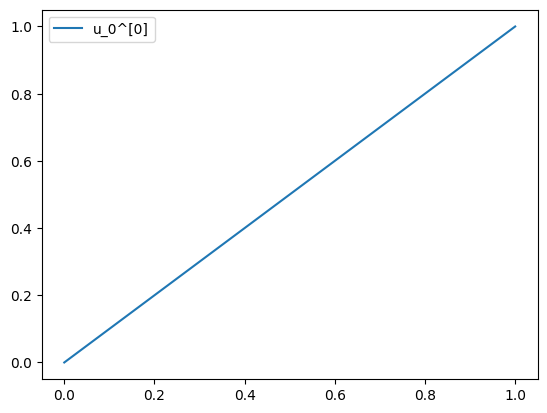

In [74]:
for i in range(M):
    plt.plot(x[:,0], u_0[i,:,0], label=f"u_0^[{i}]")

plt.legend()
plt.show()

In [75]:
psi_0 = np.zeros_like(x)

for i in range(M):
    # psi_0 += (p - u_0[i]) < 0
    psi_0 += delta_1d(p - u_0[i], omega)
psi_0 /= M

N_psi = np.linalg.norm(psi_0)
psi_0 /= N_psi

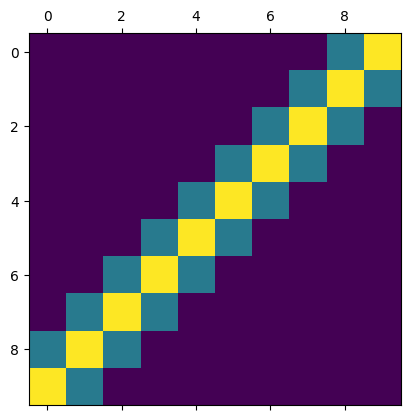

In [76]:
plt.matshow(np.rot90(psi_0))
plt.show()

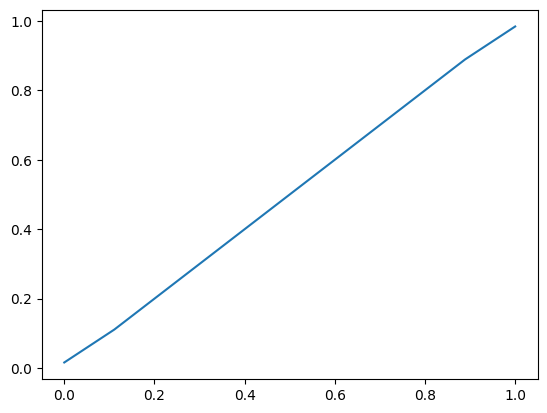

In [77]:
psi_tmp = np.copy(psi_0)
for i in range(N):
    if np.linalg.norm(psi_0[i]) > 0:
        psi_tmp[i] /= np.linalg.norm(psi_0[i])

plt.plot(x[:,0], np.sum(p * np.abs(psi_tmp) ** 2, axis=1))
plt.show()

In [80]:
# discrete_gradient_vec = np.zeros(N)

# # second order central differences (flipped)
# discrete_gradient_vec[1] = -1
# discrete_gradient_vec[-1] = 1

# discrete_gradient_vec /= 2 * h

# # evals = np.fft.fft(discrete_gradient_vec)

In [81]:
T = 0.4
N_t = 5 # time points

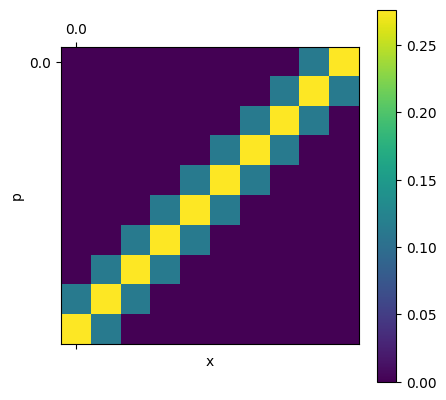

In [82]:
plt.matshow(np.rot90(psi_0))
# plt.title(f"t={t}")
plt.xlabel("x")
plt.xticks(np.arange(N, step=128), np.round(x[::128,0], decimals=2))
plt.ylabel("p")
plt.yticks(np.arange(N_p, step=128), np.round(p[0,::128], decimals=2))
plt.colorbar()
# plt.savefig(join(IMG_DIR, f"level_set_{t : 0.3f}.png"), dpi=100, facecolor="white")
plt.show()

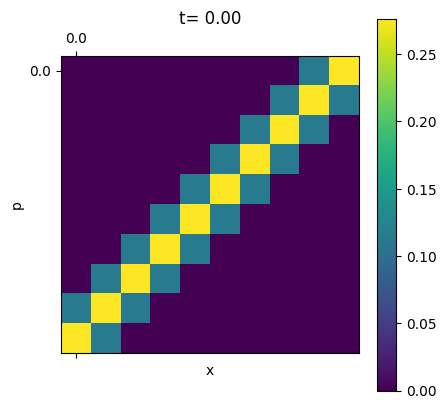

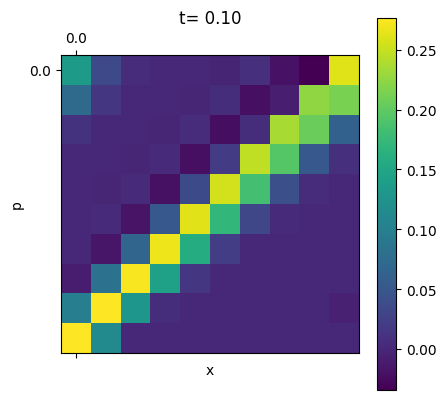

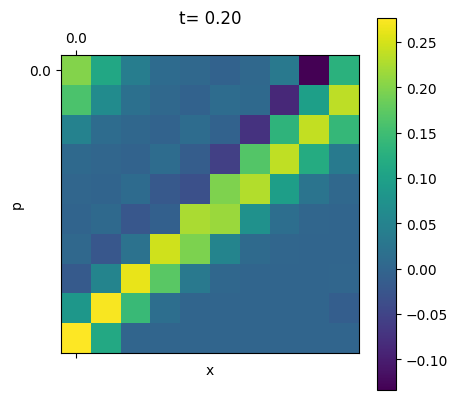

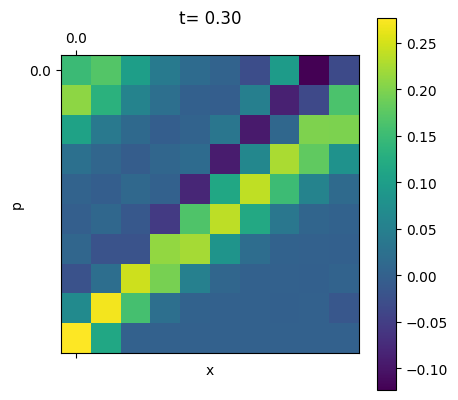

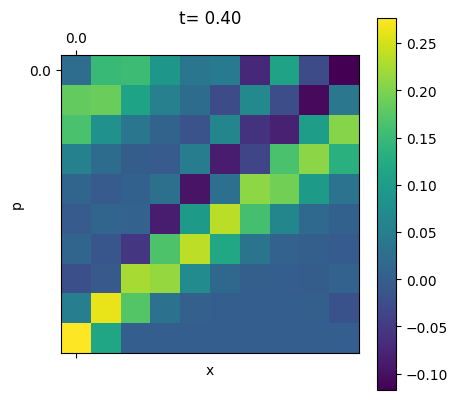

In [83]:
for t in np.linspace(0, T, N_t):
    psi = np.zeros_like(psi_0)
    for i,p_val in enumerate(np.linspace(0, 1, N_p)):

        # psi[:,i] = ifft(np.exp(-(p_val) * t * evals) * fft(psi_0[:,i])).real
        psi[:,i] = expm_multiply(-p_val * discrete_gradient * t, psi_0[:,i])
    plt.matshow(np.rot90(psi))
    plt.title(f"t={t : 0.2f}")
    plt.xlabel("x")
    plt.xticks(np.arange(N, step=128), np.round(x[::128,0], decimals=2))
    plt.ylabel("p")
    plt.yticks(np.arange(N_p, step=128), np.round(p[0,::128], decimals=2))
    plt.colorbar()
    plt.savefig(join(IMG_DIR, f"level_set_{t : 0.2f}.png"), dpi=100, facecolor="white")
    plt.show()

    # psi_tmp = np.copy(psi)
    # for i in range(N):
    #     psi_tmp[i] /= np.linalg.norm(psi[i])

    # exp_g = np.sum(p * np.abs(psi_tmp) ** 2, axis=1)
    # plt.plot(x[:,0], exp_g)
    # plt.title(f"Expectation for g(p)=p at t={t : 0.2f}")
    # plt.xlabel("x")
    # plt.xticks(np.round(x[::128,0], decimals=2))
    # plt.show()

In [84]:
psi_indicator = psi_0 > 0

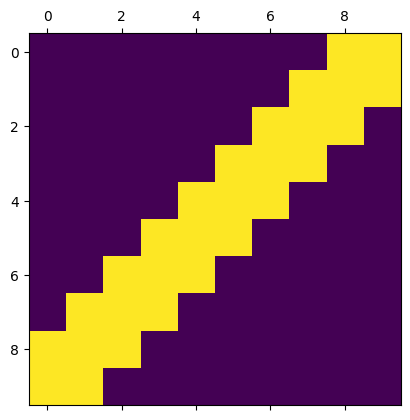

In [85]:
plt.matshow(np.rot90(psi_indicator))
plt.show()

In [86]:
def state_preparation(psi):
    # Given a bitstring psi with a single contiguous block one 1s, prepare a state whose restriction to the unary encoding is a uniform superposition of codewords which are 1

    # Number of qubits
    N = len(psi)

    circuit = Circuit()
    if encoding == "unary":
        i = 0
        while (psi[i] == 0):
            circuit.x(i)
            i += 1
        j = N-1
        while (psi[j] == 0):
            circuit.i(j)
            j -= 1
        if j >= 0:
            circuit.i(j)
        
        for k in range(i, j):
            circuit.h(k)
    elif encoding == "one-hot":
        i = 0
        while (psi[i] == 0):
            circuit.i(i)
            i += 1
        j = N-1
        while (psi[j] == 0):
            circuit.i(j)
            j -= 1
        
        if j - i == 0:
            circuit.x(i)
        else:
            for k in range(i, j+1):
                circuit.h(k)

    return circuit

def burgers_circuit(circuit, n, c, T, num_layers, R, encoding):
    # n: number of qubits in circuit
    # c: velocity
    # T: evolution time
    # L: number of Trotter layers
    # R: penalty coefficient
    
    if encoding == "unary":
        h = 1 / n
        # print(c)
        for i in range(num_layers):
            # sum of Pauli-y
            circuit.ry(range(n), c * T / (num_layers * h))
        
            # penalty part
            circuit.rz(0, 2 * T * R / num_layers)
            circuit.rz(n-1, -2 * T * R / num_layers)
            for j in np.arange(0, n-1, 2):
                circuit.zz(j, j+1, - 2 * T * R / num_layers)
            for j in np.arange(1, n-1, 2):
                circuit.zz(j, j+1, - 2 * T * R / num_layers)
                
    elif encoding == "one-hot":
        h = 1 / (n - 1)
        for i in range(num_layers):

            # XY
            for j in np.arange(0, n-1, 2):
                circuit.xy(j, j+1, c * T / (num_layers * h))
            for j in np.arange(1, n-1, 2):
                circuit.xy(j, j+1, c * T / (num_layers * h))
            circuit.xy(n-1,0, c * T * (num_layers * h))
        
            # penalty part
            circuit.rz(range(n), 2 * T * R / num_layers)
            
    return circuit

def decode_unary(n, bitstring):
    flips = 0
    first_flip = 0
    for i in range(n-1):
        if bitstring[i] != bitstring[i+1]:
            flips += 1
            first_flip = i
    
    if flips >= 2 or (bitstring[0] == 0 and flips == 1):
        return -1
    else:
        if flips == 0:
            if bitstring[0] == 0:
                return 0
            else:
                return n
        elif flips == 1:
            return first_flip + 1
        
def decode_one_hot(n, bitstring):
    sum = 0
    index = None
    for i in range(n):
        sum += bitstring[i]
        if bitstring[i] == 1 and index == None:
            index = i
    
    if sum == 1:
        return index
    else:
        return -1


def get_occurrences(N : int, measurements, num_shots : int, encoding):
    occurrences = np.zeros(N)
    # occurrences = np.zeros((4,n+1))
    bad_samples = 0
    for i in range(num_shots):
        bitstring = measurements[i]
            
        if encoding == "unary":
            index = decode_unary(n, bitstring)
        elif encoding == "one-hot":
            index = decode_one_hot(n, bitstring)
        if index >= 0:
            occurrences[index] += 1
                
    print(f"Samples in codeword subspace: {int(np.sum(occurrences))} / {num_shots}")

    return occurrences

In [87]:
use_real_machine = False

if use_real_machine:
    device = AwsDevice("arn:aws:braket:::device/qpu/ionq/ionQdevice")
else:
    # set up device: Local Simulator
    device = LocalSimulator()

print(f"Using {device.name}")

Using StateVectorSimulator


In [88]:
circuit = state_preparation(psi_indicator[:,n-1])

T  : |0|
        
q0 : -H-
        
q1 : -H-
        
q2 : -I-
        
q3 : -I-
        
q4 : -I-
        
q5 : -I-
        
q6 : -I-
        
q7 : -I-
        
q8 : -I-
        
q9 : -I-

T  : |0|
Samples in codeword subspace: 255 / 500


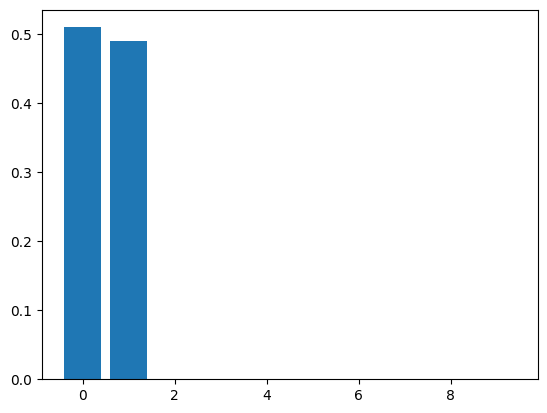

In [89]:
num_shots = 500
circuit = state_preparation(psi_indicator[:,0])

print(circuit)
task = device.run(circuit, shots=num_shots)

result = task.result()

counts = result.measurement_counts

occurrences = get_occurrences(n, result.measurements, num_shots=num_shots, encoding=encoding)
dist = occurrences / np.sum(occurrences)

plt.bar(range(N), dist)
plt.show()

In [103]:
dist_2d = np.zeros((N, N))
num_shots = 1000
p_vals = np.linspace(0, 1, N_p)

T = 0.4
for i in np.arange(0, N):
    circuit = state_preparation(psi_indicator[:,i])
    circuit = burgers_circuit(circuit, n, p_vals[i], T, num_layers=5, R=5, encoding=encoding)

    if i == 0:
        print(f"Circuit depth = {circuit.depth}")
        print(circuit)

    task = device.run(circuit, shots=num_shots)

    result = task.result()

    counts = result.measurement_counts

    occurrences = get_occurrences(N, result.measurements, num_shots=num_shots, encoding=encoding)
    if np.sum(occurrences) > 0:
        dist_2d[:,i] = occurrences / np.sum(occurrences)

Circuit depth = 16
T  : |0|   1    |        2        |   3    |   4    |        5        |   6    |   7    |        8        |   9    |   10   |       11        |   12   |   13   |       14        |   15   |
                                                                                                                                                                                            
q0 : -H-XY(0.00)----------XY(0.00)-Rz(0.80)-XY(0.00)----------XY(0.00)-Rz(0.80)-XY(0.00)----------XY(0.00)-Rz(0.80)-XY(0.00)----------XY(0.00)-Rz(0.80)-XY(0.00)----------XY(0.00)-Rz(0.80)-
        |                 |                 |                 |                 |                 |                 |                 |                 |                 |                 
q1 : -H-XY(0.00)-XY(0.00)-|--------Rz(0.80)-XY(0.00)-XY(0.00)-|--------Rz(0.80)-XY(0.00)-XY(0.00)-|--------Rz(0.80)-XY(0.00)-XY(0.00)-|--------Rz(0.80)-XY(0.00)-XY(0.00)-|--------Rz(0.80)-
                 |        |         

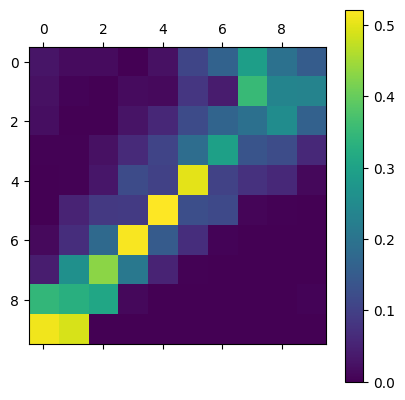

In [104]:
plt.matshow(np.rot90(dist_2d))
plt.colorbar()
plt.show()